In [54]:
# Import all necessary libraries

import numpy as np
import pandas as pd
import re
import csv

import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy.matcher import PhraseMatcher

### Data wrangling

I will start with cleaning the first dataset from glassdoor

In [55]:
#clean the first dataset from glassdoor

df1=pd.read_csv(r'C:\Users\Wambui\Desktop\Job_Market_Analysis-BI_Tools\glassdoor_data.csv')
df1.head()

,title,description,link
0,Tableau Developer,Job Title: Tableau Developer\nDescription: The...,https://www.glassdoor.com/job-listing/tableau-...
1,Power BI Designer,We are looking for a Microsoft PowerBI Designe...,https://www.glassdoor.com/job-listing/power-bi...
2,Power BI Developer,"19562\nIES Holdings\nSugar Land, Texas\n\nJob ...",https://www.glassdoor.com/job-listing/power-bi...
3,Lead Power BI Developer,We are seeking a Power BI Reporting Lead to dr...,https://www.glassdoor.com/job-listing/lead-pow...
4,Power BI Developer,Piper Companies is looking for a Power BI Deve...,https://www.glassdoor.com/job-listing/power-bi...


In [56]:
#handle missingness, drop any row which missing values
df1.dropna(inplace=True)

For this analysis, I also want to examine if the preferrence for Power BI or Tableau is based on the specific data role, for example Data Analyst or Data Manager. We know the same job role, technically can be referred to in a myriad of ways, depending on the company. So the next step is to categorize the scrapped job titles into what I am calling 'core titles'. This way a 'Sales BI Analyst' is simply a 'BI Analyst', making analysis much easier.

In [57]:
#first check the variety of titles
df1['title'].value_counts()

title
Business Intelligence Analyst                             34
Power BI Developer                                        26
Data Analyst                                              21
Senior Power BI Developer                                 14
Tableau Developer                                         12
                                                          ..
Power BI Engineer (DAX, Power Query, Power BI Service)     1
Data Analyst - IT                                          1
EPIC Inpatient BI Developer                                1
Senior Business Intelligence Analyst                       1
Vice President, Analytics                                  1
Name: count, Length: 356, dtype: int64

In [58]:
title_keywords = {
    "data engineer": ["engineer", "engineering"],
    "data manager": ["manager", "management", "data director","president"],
    "data analyst": ["data analyst", "analytics", "analysis"],
    "bi analyst": ["bi analyst", "business intelligence analyst","business analyst","business intelligence","market intelligence"],
    "bi developer": ["bi developer", "business intelligence developer","developer","power bi"],
    "data scientist": ["scientist", "science","artificial intelligence"],
    "data architect": ["architect", "architecture"],
    "data specialist": ["specialist"],
    "data steward": ["steward", "librarian"],
    "data coordinator": ["coordinator", "data coordinator"],
    "data strategist": ["strategist", "strategy"],
    "data quality specialist": ["quality specialist", "quality assurance", "data quality"],
    "data educator":["lecturer","professor"],
    "data governance":["data governance"],
    "business development":["business development"]
    }


In [59]:
def get_core_title(title):
    title_lower = title.lower()

    # Check each key in the dictionary
    for core_title, keywords in title_keywords.items():
        # If any keyword matches, return the core job title
        if any(keyword in title_lower for keyword in keywords):
            return core_title
    
    return "unknown"  #if no match found

In [60]:
df1["core_title"] = df1["title"].apply(get_core_title)
df1[["title", "core_title"]]

,title,core_title
0,Tableau Developer,bi developer
1,Power BI Designer,bi developer
2,Power BI Developer,bi developer
3,Lead Power BI Developer,bi developer
4,Power BI Developer,bi developer
...,...,...
794,Data Analyst - IT,data analyst
795,Data Visualization Specialist,data specialist
796,EPIC Inpatient BI Developer,bi developer
797,Senior Business Intelligence Analyst,bi analyst


In [61]:
df1.core_title.value_counts()

core_title
bi developer        266
bi analyst          148
data analyst        124
unknown             104
data engineer        54
data manager         40
data specialist      33
data strategist      11
data architect        7
data coordinator      3
Name: count, dtype: int64

In [62]:
df1['source']='glassdoor'
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 790 entries, 0 to 798
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        790 non-null    object
 1   description  790 non-null    object
 2   link         790 non-null    object
 3   core_title   790 non-null    object
 4   source       790 non-null    object
dtypes: object(5)
memory usage: 37.0+ KB


Now I will clean the myjobmag dataset

In [63]:
df2=pd.read_csv(r'C:\Users\Wambui\Desktop\Job_Market_Analysis-BI_Tools\myjobmag_data.csv')
df2.head()

,title,description,link
0,Manager- Data Transformation Intelligence and ...,"Our ideal candidate is self-motivated, adaptab...",https://www.myjobmag.co.ke/job/manager-data-tr...
1,Manager – Data Transformation Intelligence and...,Job Summary\ninSupply Health Ltd. is seeking a...,https://www.myjobmag.co.ke/job/manager-data-tr...
2,Business Intelligence Analyst at Gertrude's Ch...,Key Responsibilities\nCollaborate with various...,https://www.myjobmag.co.ke/job/business-intell...
3,Senior Analyst: Business Intelligence at Cellu...,"ROLE PURPOSE:\nThe Senior Analyst, Business In...",https://www.myjobmag.co.ke/job/senior-analyst-...
4,Business Intelligence Analyst at SENRI Ltd. (A...,"As a Business Intelligence(BI) Analyst, you wi...",https://www.myjobmag.co.ke/job/business-intell...


In [64]:
#handle missingness, drop any row which missing values
df2.dropna(inplace=True)

Notice, for the job titles, they also include the company, we do not need this information, so I will use a regex function to remove all words after 'at' assuming that the words preceeding that are the actualy job titles. Some titles also have '-', the function will remove this also.

In [65]:
def remove_company_name(title):
    return re.sub(r'\s+(at|\||-)\s+.*', '', title, flags=re.IGNORECASE)

In [66]:
df2['cleaned_title']=df2['title'].apply(remove_company_name)
df2

,title,description,link,cleaned_title
0,Manager- Data Transformation Intelligence and ...,"Our ideal candidate is self-motivated, adaptab...",https://www.myjobmag.co.ke/job/manager-data-tr...,Manager- Data Transformation Intelligence and ...
1,Manager – Data Transformation Intelligence and...,Job Summary\ninSupply Health Ltd. is seeking a...,https://www.myjobmag.co.ke/job/manager-data-tr...,Manager – Data Transformation Intelligence and...
2,Business Intelligence Analyst at Gertrude's Ch...,Key Responsibilities\nCollaborate with various...,https://www.myjobmag.co.ke/job/business-intell...,Business Intelligence Analyst
3,Senior Analyst: Business Intelligence at Cellu...,"ROLE PURPOSE:\nThe Senior Analyst, Business In...",https://www.myjobmag.co.ke/job/senior-analyst-...,Senior Analyst: Business Intelligence
4,Business Intelligence Analyst at SENRI Ltd. (A...,"As a Business Intelligence(BI) Analyst, you wi...",https://www.myjobmag.co.ke/job/business-intell...,Business Intelligence Analyst
...,...,...,...,...
892,Business Development Internship at Adjacent Po...,Eligibility:\nInternship at APF is open to can...,https://www.myjobmag.co.ke/job/business-develo...,Business Development Internship
893,Team Leader - Corporate Business Development (...,Key Responsibilities\nBusiness Growth & Strate...,https://www.myjobmag.co.ke/job/team-leader-cor...,Team Leader
894,Real Estate Business Partner CU CEA at Ericsson,What you will do:\nOwn and build strategic rel...,https://www.myjobmag.co.ke/job/real-estate-bus...,Real Estate Business Partner CU CEA
895,Relationship Officer- Business Development at ...,Job Summary:\nTo achieve business growth for t...,https://www.myjobmag.co.ke/job/relationship-of...,Relationship Officer- Business Development


In [67]:
df2["core_title"] = df2["cleaned_title"].apply(get_core_title)
df2[["cleaned_title", "core_title"]]

,cleaned_title,core_title
0,Manager- Data Transformation Intelligence and ...,data manager
1,Manager – Data Transformation Intelligence and...,data manager
2,Business Intelligence Analyst,bi analyst
3,Senior Analyst: Business Intelligence,bi analyst
4,Business Intelligence Analyst,bi analyst
...,...,...
892,Business Development Internship,business development
893,Team Leader,unknown
894,Real Estate Business Partner CU CEA,unknown
895,Relationship Officer- Business Development,business development


In [68]:
df2['core_title'].value_counts()

core_title
unknown                    253
data manager               192
business development       153
bi analyst                  72
data analyst                64
data engineer               56
data scientist              45
data educator               17
data specialist             17
bi developer                16
data coordinator             4
data governance              3
data quality specialist      2
data steward                 1
data strategist              1
data architect               1
Name: count, dtype: int64

In [69]:
df2.loc[df2['core_title']=='unknown'].tail(5)

,title,description,link,cleaned_title,core_title
886,Part-Time Associate Faculty - School of Busine...,Qualification\nTo qualify for appointment a ca...,https://www.myjobmag.co.ke/job/part-time-assoc...,Part-Time Associate Faculty,unknown
887,Digital Agency - Business Development & Sales ...,Business Development & Revenue Growth\nDevelop...,https://www.myjobmag.co.ke/job/digital-agency-...,Digital Agency,unknown
891,Head Business Planning at CIC Insurance,"PURPOSE:\nReporting to the Group Director, Bus...",https://www.myjobmag.co.ke/job/head-business-p...,Head Business Planning,unknown
893,Team Leader - Corporate Business Development (...,Key Responsibilities\nBusiness Growth & Strate...,https://www.myjobmag.co.ke/job/team-leader-cor...,Team Leader,unknown
894,Real Estate Business Partner CU CEA at Ericsson,What you will do:\nOwn and build strategic rel...,https://www.myjobmag.co.ke/job/real-estate-bus...,Real Estate Business Partner CU CEA,unknown


In [70]:
df2.loc[df2['core_title']=='business development'].tail(3)

,title,description,link,cleaned_title,core_title
888,Business Development & Operations Executive at...,Business Development & Sales Growth\nIdentify ...,https://www.myjobmag.co.ke/job/business-develo...,Business Development & Operations Executive,business development
892,Business Development Internship at Adjacent Po...,Eligibility:\nInternship at APF is open to can...,https://www.myjobmag.co.ke/job/business-develo...,Business Development Internship,business development
895,Relationship Officer- Business Development at ...,Job Summary:\nTo achieve business growth for t...,https://www.myjobmag.co.ke/job/relationship-of...,Relationship Officer- Business Development,business development


From the looks of it, when I scrapped the MyJobMag Kenya website using the key word 'business intelligence analyst' it also picked roles that were related to business, such as 'business development'. Since these are not roles in the data field, I will drop them, together with any role categorized as 'unknown'.

In [71]:
df2_cleaned = df2.loc[~df2['core_title'].isin(['business development', 'unknown'])]


In [72]:
df2_cleaned['core_title'].value_counts()

core_title
data manager               192
bi analyst                  72
data analyst                64
data engineer               56
data scientist              45
data educator               17
data specialist             17
bi developer                16
data coordinator             4
data governance              3
data quality specialist      2
data steward                 1
data strategist              1
data architect               1
Name: count, dtype: int64

In [73]:
df2_cleaned['source']='myjobmag'
df2_cleaned.head(3)

C:\Users\Wambui\AppData\Local\Temp\ipykernel_12012\3101916060.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_cleaned['source']='myjobmag'


,title,description,link,cleaned_title,core_title,source
0,Manager- Data Transformation Intelligence and ...,"Our ideal candidate is self-motivated, adaptab...",https://www.myjobmag.co.ke/job/manager-data-tr...,Manager- Data Transformation Intelligence and ...,data manager,myjobmag
1,Manager – Data Transformation Intelligence and...,Job Summary\ninSupply Health Ltd. is seeking a...,https://www.myjobmag.co.ke/job/manager-data-tr...,Manager – Data Transformation Intelligence and...,data manager,myjobmag
2,Business Intelligence Analyst at Gertrude's Ch...,Key Responsibilities\nCollaborate with various...,https://www.myjobmag.co.ke/job/business-intell...,Business Intelligence Analyst,bi analyst,myjobmag


Now that I have 2 clean and categorized datasets, I can go ahead and merge them together.

In [74]:
cleaned_df=pd.concat([df1,df2_cleaned],ignore_index=True)
df =cleaned_df.drop(['link','cleaned_title'],axis=1)


#### Using PhraseMatcher from SpaCy to extract keywords from the job descriptions

In [75]:
#load the english model from spacy
nlp_en = spacy.load('en_core_web_sm')

In [76]:
# Initialize the PhraseMatcher
matcher = PhraseMatcher(nlp_en.vocab,attr='LOWER')

#common phrases for power BI and tableau that will be searched
power_bi_phrases = ["Power BI", "Microsoft Power BI", "PowerBI","Power-BI","Ms Power BI"]
tableau_phrases = ["Tableau", "Tableau Desktop", "Tableau Online",]

pattern1 = [nlp_en(text) for text in power_bi_phrases]
pattern2 = [nlp_en(text) for text in tableau_phrases]

matcher.add("POWER_BI",pattern1)
matcher.add("TABLEAU",pattern2)

In [77]:
def find_all_matches(text):
    if pd.isna(text):
        return None
    doc = nlp_en(text.lower())
    matches = matcher(doc)
    
    found_tools = {
        'power_bi_mentioned': 0,
        'tableau_mentioned': 0
    }
    
    for match_id, start, end in matches:
        tool_name = nlp_en.vocab.strings[match_id]
        if tool_name == 'POWER_BI':
            found_tools['power_bi_mentioned'] = 1
        elif tool_name == 'TABLEAU':
            found_tools['tableau_mentioned'] = 1
    
    return found_tools

# Step 4: Apply the function to the DataFrame
df[['power_bi_mentioned', 'tableau_mentioned']] = df['description'].apply(
    lambda x: pd.Series(find_all_matches(x))
)



#### Using simple regex to extract years of experience from each job description

In [78]:
def extract_max_years_experience(job_description):
    patterns = [
        r'(\d+)\+?\s*years?',                  # for "3 years", "5+ years"
        r'at least\s+(\d+)\s*years?',          # for "at least 4 years"
        r'minimum of\s+(\d+)\s*years?',        # for "minimum of 2 years"
        r'(\d+)-(\d+)\s*years?'                # for "2-4 years"
    ]
    
    years = []
    for pattern in patterns:
        matches = re.findall(pattern, job_description, flags=re.IGNORECASE)
        for match in matches:
            if isinstance(match, tuple) and all(match):  # for ranges like "2-4 years"
                years.extend(map(int, match))
            else:
                years.append(int(match if not isinstance(match, tuple) else match[0]))
                
    years=[y for y in years if y <= 15]
    return max(years) if years else 'unspecified'




In [79]:
df['max_years_experience']=df['description'].apply(extract_max_years_experience)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   title                 1281 non-null   object
 1   description           1281 non-null   object
 2   core_title            1281 non-null   object
 3   source                1281 non-null   object
 4   power_bi_mentioned    1281 non-null   int64 
 5   tableau_mentioned     1281 non-null   int64 
 6   max_years_experience  1281 non-null   object
dtypes: int64(2), object(5)
memory usage: 70.2+ KB


In [81]:
df['max_years_experience'].value_counts()

max_years_experience
unspecified    393
5              282
3              164
2              103
7               77
4               70
8               54
10              44
6               32
1               22
15              14
12              10
9               10
14               4
13               2
Name: count, dtype: int64

## Data Analysis

#### Q1: Which is the most often requested by employers based on the frequency of mentions in the job descriptions?

In [82]:
demand_per_tool=df.groupby('source')[['power_bi_mentioned','tableau_mentioned']].sum().reset_index()
demand_per_tool

,source,power_bi_mentioned,tableau_mentioned
0,glassdoor,593,441
1,myjobmag,112,76


In [83]:
demand_melted= demand_per_tool.melt(id_vars="source", 
                                value_vars=["power_bi_mentioned", "tableau_mentioned"],
                                var_name="tool", 
                                value_name="count")

In [ ]:
demand_melted

,source,tool,count
0,glassdoor,power_bi_mentioned,593
1,myjobmag,power_bi_mentioned,112
2,glassdoor,tableau_mentioned,441
3,myjobmag,tableau_mentioned,76


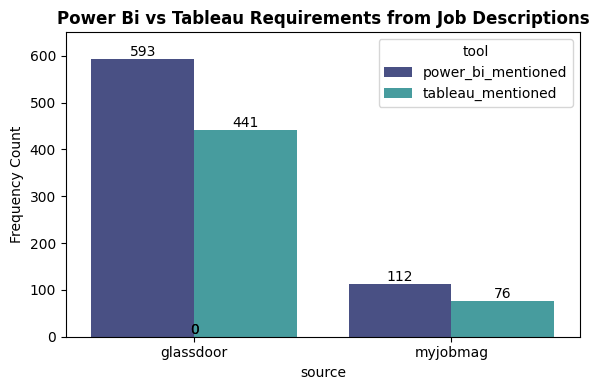

In [133]:
plt.figure(figsize=(6,4))

ax=sns.barplot(data=demand_melted, x='source', y='count', hue='tool',palette='mako')

for p in ax.patches:
    ax.annotate(str(format(p.get_height(), '.0f')), 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
    
plt.title('Power Bi vs Tableau Requirements from Job Descriptions',loc='center',fontweight='bold')
plt.ylabel('Frequency Count')
plt.ylim(0,650)
#legend.get_frame().set_facecolor('grey')
plt.tight_layout()
plt.show()

#### Q2: Is there a link between the BI tool requested by employees and the specific data role?

In [85]:
demand_per_job_role=df.groupby('core_title')[['power_bi_mentioned','tableau_mentioned']].sum().reset_index()
demand_per_job_role

,core_title,power_bi_mentioned,tableau_mentioned
0,bi analyst,141,98
1,bi developer,231,79
2,data analyst,131,118
3,data architect,6,5
4,data coordinator,2,3
5,data educator,0,0
6,data engineer,58,37
7,data governance,0,0
8,data manager,34,38
9,data quality specialist,1,1


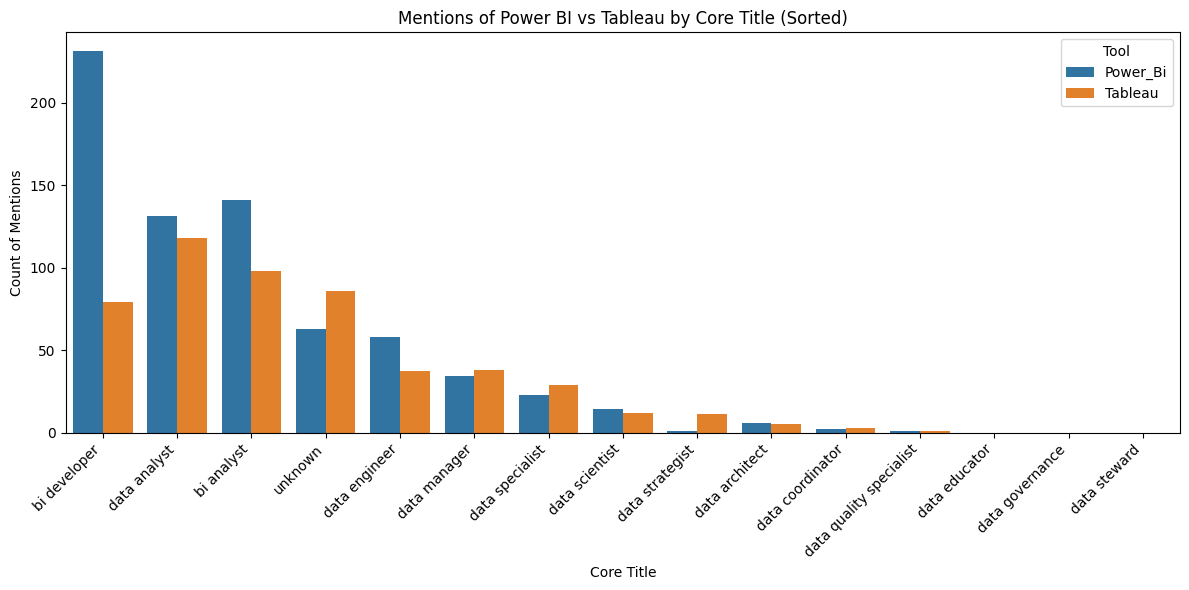

In [86]:
# Compute totals for sorting
demand_per_job_role["total_mentions"] = demand_per_job_role["power_bi_mentioned"] + demand_per_job_role["tableau_mentioned"]

# Sort by total mentions (descending)
demand_per_job_role = demand_per_job_role.sort_values("total_mentions", ascending=False)

# Reshape into long format
df_long = demand_per_job_role.melt(
    id_vars="core_title", 
    value_vars=["power_bi_mentioned", "tableau_mentioned"],
    var_name="Tool", 
    value_name="Mentions"
)

# Make labels nicer
df_long["Tool"] = df_long["Tool"].str.replace("_mentioned","").str.title()

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=df_long, x="core_title", y="Mentions", hue="Tool")
plt.xticks(rotation=45, ha="right")
plt.title("Mentions of Power BI vs Tableau by Core Title (Sorted)")
plt.xlabel("Core Title")
plt.ylabel("Count of Mentions")
plt.legend(title="Tool")
plt.tight_layout()
plt.show()

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   title                 1281 non-null   object
 1   description           1281 non-null   object
 2   core_title            1281 non-null   object
 3   source                1281 non-null   object
 4   power_bi_mentioned    1281 non-null   int64 
 5   tableau_mentioned     1281 non-null   int64 
 6   max_years_experience  1281 non-null   object
dtypes: int64(2), object(5)
memory usage: 70.2+ KB
